In [1]:
import numpy as np
from tqdm import tqdm
import time
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# TORCH MODULES FOR METRICS COMPUTATION :
import torch
from torch.utils.data import Dataset
from torch import nn
from torch.utils.data import random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics.classification import MultilabelF1Score
from torchmetrics.classification import MultilabelAccuracy

MAIN_DIR = '/kaggle/input/cafa-6-protein-function-prediction'

class config:
    train_sequences_path = MAIN_DIR  + "/Train/train_sequences.fasta"
    train_labels_path = MAIN_DIR + "/Train/train_terms.tsv"
    test_sequences_path = MAIN_DIR + "/Test/testsuperset.fasta"
    
    num_labels = 800
    n_epochs = 5
    batch_size = 128
    lr = 0.01
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
class ProteinSequenceDataset(Dataset):
    
    def __init__(self, train_emb, train_id, datatype):
        super(ProteinSequenceDataset).__init__()
        
        self.datatype = datatype
        embeds = np.load(train_emb)
        ids = np.load(train_id)
            
        embeds_list = []
        for l in range(embeds.shape[0]):
            embeds_list.append(embeds[l,:])
        self.df = pd.DataFrame(data={"EntryID": ids, "embed" : embeds_list})
        
        if datatype=="train":
            np_labels = np.load(
                "/kaggle/input/cafa6top500"+"/train_targets_top"+str(config.num_labels)+".npy")
            df_labels = pd.DataFrame(self.df['EntryID'])
            df_labels['labels_vect']=[row for row in np_labels]
            self.df = self.df.merge(df_labels, on="EntryID")
            
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        embed = torch.tensor(self.df.iloc[index]["embed"] , dtype = torch.float32)
        if self.datatype=="train":
            targets = torch.tensor(self.df.iloc[index]["labels_vect"], dtype = torch.float32)
            return embed, targets
        if self.datatype=="test":
            id = self.df.iloc[index]["EntryID"]
            return embed, id

In [3]:
train_emb = "/kaggle/input/ensumble-data/train_concat_normalized_embeddings.npy"
train_id = "/kaggle/input/ensumble-data/train_concat_normalized_ids.npy"
test_emb = "/kaggle/input/ensumble-data/test_concat_normalized_embeddings.npy"
test_id = "/kaggle/input/ensumble-data/test_concat_normalized_ids.npy"

train_dataset = ProteinSequenceDataset(train_emb, train_id, datatype="train")
test_dataset = ProteinSequenceDataset(test_emb, test_id, datatype="test")

In [4]:
train_dataset

In [5]:
class MultiLayerPerceptron(torch.nn.Module):

    def __init__(self, input_dim, num_classes):
        super(MultiLayerPerceptron, self).__init__()

        self.linear1 = torch.nn.Linear(input_dim, 864)
        self.activation1 = torch.nn.ReLU() 
        self.linear2 = torch.nn.Linear(864, 712)
        self.activation2 = torch.nn.ReLU()
        self.linear3 = torch.nn.Linear(712, num_classes)
      

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation1(x)
        x = self.linear2(x)
        x = self.activation2(x)
        x = self.linear3(x)
        return x

In [6]:


def train_model(train_dataset, model, train_size=0.9):
        
    train_set, val_set = random_split(train_dataset, lengths = [int(len(train_dataset)*train_size), len(train_dataset)-int(len(train_dataset)*train_size)])
    train_dataloader = torch.utils.data.DataLoader(train_set, batch_size=config.batch_size, shuffle=True)
    val_dataloader = torch.utils.data.DataLoader(val_set, batch_size=config.batch_size, shuffle=True)

    optimizer = torch.optim.Adam(model.parameters(), lr = config.lr)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=1)
    CrossEntropy = torch.nn.CrossEntropyLoss()
    f1_score = MultilabelF1Score(num_labels=config.num_labels).to(config.device)
    n_epochs = config.n_epochs

    print("BEGIN TRAINING WITH ESM2 EMBEDDINGS...")
    train_loss_history=[]
    val_loss_history=[]
    
    train_f1score_history=[]
    val_f1score_history=[]
    for epoch in range(n_epochs):
        print("EPOCH ", epoch+1)
        ## TRAIN PHASE :
        losses = []
        scores = []
        for embed, targets in tqdm(train_dataloader):
            embed, targets = embed.to(config.device), targets.to(config.device)
            optimizer.zero_grad()
            preds = model(embed)
            loss= CrossEntropy(preds, targets)
            score=f1_score(preds, targets)
            losses.append(loss.item()) 
            scores.append(score.item())
            loss.backward()
            optimizer.step()
        avg_loss = np.mean(losses)
        avg_score = np.mean(scores)
        print("Running Average TRAIN Loss : ", avg_loss)
        print("Running Average TRAIN F1-Score : ", avg_score)
        train_loss_history.append(avg_loss)
        train_f1score_history.append(avg_score)
        
        ## VALIDATION PHASE : 
        losses = []
        scores = []
        for embed, targets in val_dataloader:
            embed, targets = embed.to(config.device), targets.to(config.device)
            preds = model(embed)
            loss= CrossEntropy(preds, targets)
            score=f1_score(preds, targets)
            losses.append(loss.item())
            scores.append(score.item())
        avg_loss = np.mean(losses)
        avg_score = np.mean(scores)
        print("Running Average VAL Loss : ", avg_loss)
        print("Running Average VAL F1-Score : ", avg_score)
        val_loss_history.append(avg_loss)
        val_f1score_history.append(avg_score)
        
        scheduler.step(avg_loss)
        print("\n")
        
    print("TRAINING FINISHED")
    print("FINAL TRAINING SCORE : ", train_f1score_history[-1])
    print("FINAL VALIDATION SCORE : ", val_f1score_history[-1])
    
    losses_history = {"train" : train_loss_history, "val" : val_loss_history}
    scores_history = {"train" : train_f1score_history, "val" : val_f1score_history}
    
    return model, losses_history, scores_history

model = MultiLayerPerceptron(input_dim=2304, num_classes=config.num_labels).to(config.device)

esm2_model, esm2_losses, esm2_scores = train_model(train_dataset, model)

BEGIN TRAINING WITH ESM2 EMBEDDINGS...
EPOCH  1


100%|██████████| 580/580 [00:36<00:00, 16.06it/s]


Running Average TRAIN Loss :  20.496572144278165
Running Average TRAIN F1-Score :  0.003904123546491409
Running Average VAL Loss :  20.06880038334773
Running Average VAL F1-Score :  0.003836176021454426


EPOCH  2


100%|██████████| 580/580 [00:40<00:00, 14.35it/s]


Running Average TRAIN Loss :  19.86974116358264
Running Average TRAIN F1-Score :  0.003959040847960217
Running Average VAL Loss :  19.918966586773212
Running Average VAL F1-Score :  0.004110517238195126


EPOCH  3


...

Running Average TRAIN Loss :  19.78638238084727
Running Average TRAIN F1-Score :  0.004171899221998093
Running Average VAL Loss :  19.850682478684647
Running Average VAL F1-Score :  0.004398948849680332


EPOCH  4


100%|██████████| 580/580 [00:40<00:00, 14.18it/s]


Running Average TRAIN Loss :  19.703116382401564
Running Average TRAIN F1-Score :  0.004646840694777925
Running Average VAL Loss :  19.727209135202262
Running Average VAL F1-Score :  0.00497976467013359


EPOCH  5


100%|██████████| 580/580 [00:41<00:00, 14.04it/s]


Running Average TRAIN Loss :  19.670358838706182
Running Average TRAIN F1-Score :  0.00495758197984883
Running Average VAL Loss :  19.782076894319975
Running Average VAL F1-Score :  0.005053546018182085


TRAINING FINISHED
FINAL TRAINING SCORE :  0.00495758197984883
FINAL VALIDATION SCORE :  0.005053546018182085


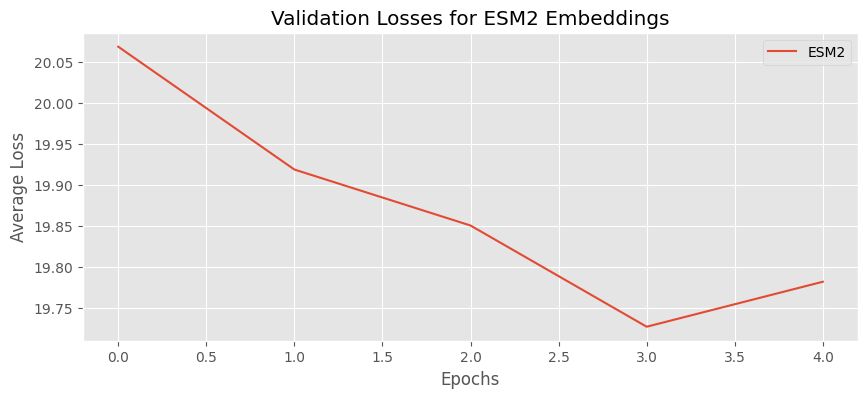

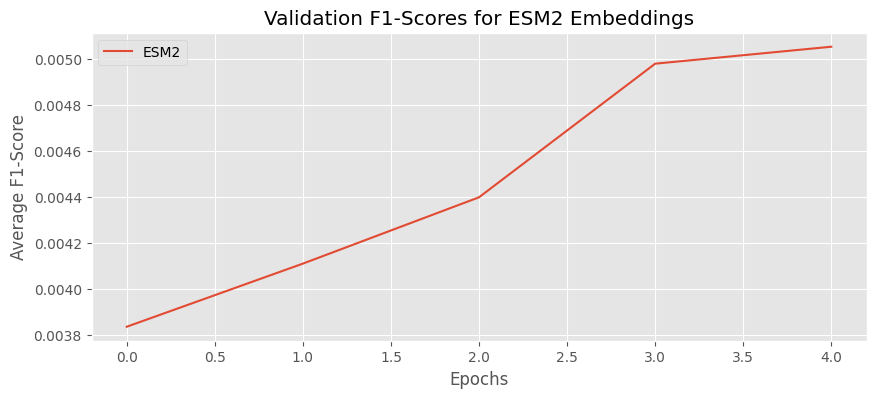

In [7]:
plt.figure(figsize = (10, 4))
plt.plot(esm2_losses["val"], label = "ESM2") 
plt.title("Validation Losses for ESM2 Embeddings")
plt.xlabel("Epochs")
plt.ylabel("Average Loss")
plt.legend()
plt.show()

plt.figure(figsize = (10, 4))
plt.plot(esm2_scores["val"], label = "ESM2")
plt.title("Validation F1-Scores for ESM2 Embeddings")
plt.xlabel("Epochs")
plt.ylabel("Average F1-Score")
plt.legend()
plt.show()

In [8]:
def predict(test_dataset):
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    model = esm2_model
    model.eval()
    
    labels = pd.read_csv(config.train_labels_path, sep = "\t")
    top_terms = labels.groupby("term")["EntryID"].count().sort_values(ascending=False)
    labels_names = top_terms[:config.num_labels].index.values
    print("GENERATE PREDICTION FOR TEST SET...")

    ids_ = np.empty(shape=(len(test_dataloader)*config.num_labels,), dtype=object)
    go_terms_ = np.empty(shape=(len(test_dataloader)*config.num_labels,), dtype=object)
    confs_ = np.empty(shape=(len(test_dataloader)*config.num_labels,), dtype=np.float32)

    for i, (embed, id) in tqdm(enumerate(test_dataloader)):
        embed = embed.to(config.device)
        confs_[i*config.num_labels:(i+1)*config.num_labels] = torch.nn.functional.sigmoid(model(embed)).squeeze().detach().cpu().numpy()
        ids_[i*config.num_labels:(i+1)*config.num_labels] = id[0]
        go_terms_[i*config.num_labels:(i+1)*config.num_labels] = labels_names

    submission_df = pd.DataFrame(data={"Id" : ids_, "GO term" : go_terms_, "Confidence" : confs_})
    print("PREDICTIONS DONE")
    return submission_df

submission_df = predict(test_dataset)

submission_df.to_csv('submission.tsv', sep='\t', header=False, index=False)

GENERATE PREDICTION FOR TEST SET...


224309it [03:36, 1036.09it/s]


PREDICTIONS DONE
